In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

In [31]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [32]:
print(fraud_df.shape)
print(ip_df.shape)

(151112, 11)
(138846, 3)


In [33]:
fraud_df['signup_time'] = pd.to_datetime(
    fraud_df['signup_time']
)

fraud_df['purchase_time'] = pd.to_datetime(
    fraud_df['purchase_time']
)

In [34]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


Geolocation Integration

In [35]:
fraud_df['ip_address'] = fraud_df['ip_address'].astype(np.int64)

ip_df['lower_bound_ip_address'] = (
    ip_df['lower_bound_ip_address']
    .astype(np.int64)
)

ip_df['upper_bound_ip_address'] = (
    ip_df['upper_bound_ip_address']
    .astype(np.int64)
)

In [36]:
fraud_df = fraud_df.sort_values('ip_address')

ip_df = ip_df.sort_values(
    'lower_bound_ip_address'
)

Merge Country Information

In [37]:
fraud_geo = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [38]:
fraud_geo = fraud_geo[
    fraud_geo['ip_address']
    <= fraud_geo['upper_bound_ip_address']
]

In [39]:
fraud_geo[['ip_address', 'country']].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [40]:
fraud_geo['country'].isnull().sum()

np.int64(0)

Fraud by Country Analysis

In [41]:
country_fraud = (
    fraud_geo.groupby('country')['class']
    .mean()
    .sort_values(ascending=False)
)

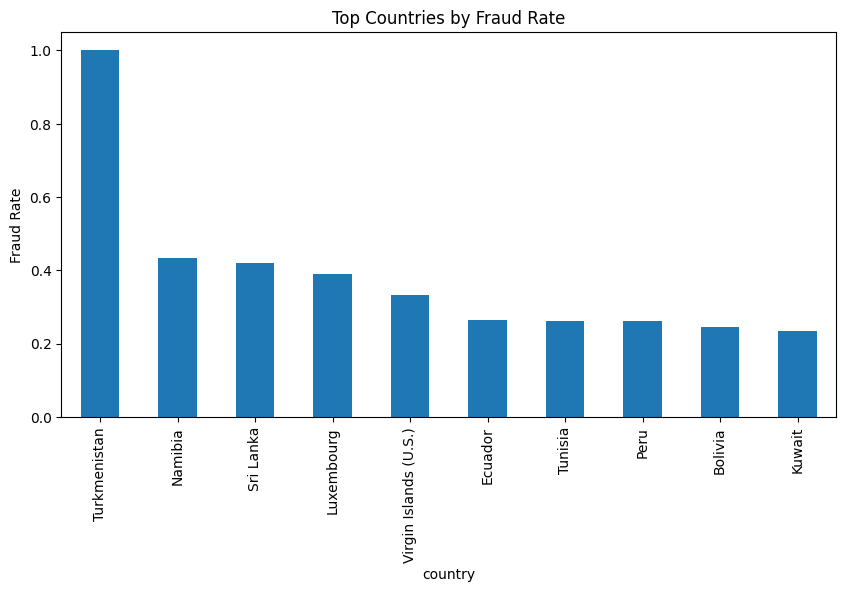

In [42]:
plt.figure(figsize=(10,5))

country_fraud.head(10).plot(
    kind='bar'
)

plt.title("Top Countries by Fraud Rate")
plt.ylabel("Fraud Rate")

plt.show()

Feature Engineering

Time Since Signup

In [43]:
fraud_geo['time_since_signup'] = (
    fraud_geo['purchase_time']
    - fraud_geo['signup_time']
).dt.total_seconds()

In [44]:
fraud_geo['time_since_signup'].describe()

count    1.291460e+05
mean     4.927250e+06
std      3.129629e+06
min      1.000000e+00
25%      2.180227e+06
50%      4.925322e+06
75%      7.643550e+06
max      1.036797e+07
Name: time_since_signup, dtype: float64

In [46]:
fraud_geo['hour_of_day'] = (
    fraud_geo['purchase_time']
    .dt.hour
)

In [47]:
fraud_geo['day_of_week'] = (
    fraud_geo['purchase_time']
    .dt.dayofweek
)

User Transaction Count

In [48]:

fraud_geo['user_transaction_count'] = (
    fraud_geo.groupby('user_id')
    ['user_id']
    .transform('count')
)


In [49]:
fraud_geo['device_transaction_count'] = (
    fraud_geo.groupby('device_id')
    ['device_id']
    .transform('count')
)

In [50]:
fraud_geo[
    [
        'time_since_signup',
        'hour_of_day',
        'day_of_week',
        'user_transaction_count',
        'device_transaction_count'
    ]
].head()

,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count
634,3632215.0,3,6,1,1
635,1231637.0,20,2,1,1
636,1997534.0,23,5,1,2
637,7640897.0,16,5,1,1
638,10249579.0,4,1,1,1


In [51]:
fraud_geo.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'lower_bound_ip_address', 'upper_bound_ip_address', 'country',
       'time_since_signup', 'hour_of_day', 'day_of_week',
       'user_transaction_count', 'device_transaction_count'],
      dtype='str')

In [52]:
fraud_model = fraud_geo.drop(
    columns=[
        'user_id',
        'device_id',
        'signup_time',
        'purchase_time',
        'ip_address',
        'lower_bound_ip_address',
        'upper_bound_ip_address'
    ]
)

In [53]:
fraud_model.head()

,purchase_value,source,browser,sex,age,class,country,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count
634,47,SEO,Safari,F,30,0,Australia,3632215.0,3,6,1,1
635,15,SEO,Chrome,F,34,0,Thailand,1231637.0,20,2,1,1
636,44,Ads,IE,M,29,0,China,1997534.0,23,5,1,2
637,55,Direct,Chrome,F,30,0,China,7640897.0,16,5,1,1
638,51,SEO,Chrome,F,37,0,Thailand,10249579.0,4,1,1,1


Separate Features and Target

In [54]:
X = fraud_model.drop('class', axis=1)

y = fraud_model['class']

In [55]:
print(X.shape)
print(y.shape)

(129146, 11)
(129146,)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
print(X_train.shape)
print(X_test.shape)

(103316, 11)
(25830, 11)


In [58]:
X_train.dtypes

purchase_value                int64
source                          str
browser                         str
sex                             str
age                           int64
country                         str
time_since_signup           float64
hour_of_day                   int32
day_of_week                   int32
user_transaction_count        int64
device_transaction_count      int64
dtype: object

In [59]:
X_train = pd.get_dummies(
    X_train,
    columns=['source', 'browser', 'sex', 'country'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['source', 'browser', 'sex', 'country'],
    drop_first=True
)

In [60]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [61]:
print(X_train.shape)
print(X_test.shape)

(103316, 188)
(25830, 188)


In [62]:
numeric_cols = [
    'purchase_value',
    'age',
    'time_since_signup',
    'hour_of_day',
    'day_of_week',
    'user_transaction_count',
    'device_transaction_count'
]

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [64]:
X_train.head()

,purchase_value,age,time_since_signup,hour_of_day,day_of_week,user_transaction_count,device_transaction_count,source_Direct,source_SEO,browser_FireFox,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
11441,-0.812480,0.100785,0.029809,-0.505315,1.487905,0.0,-0.259403,True,False,False,...,True,False,False,False,False,False,False,False,False,False
97117,-0.594175,-0.015393,0.858939,-0.649814,0.490721,0.0,0.118793,False,True,False,...,False,False,False,False,False,False,False,False,False,False
85631,-1.358241,-0.131571,1.314263,1.517669,-1.503647,0.0,-0.259403,True,False,False,...,False,False,False,False,False,False,False,False,False,False
109419,-1.030784,-1.060995,1.632952,-1.227810,-1.005055,0.0,-0.259403,False,False,False,...,False,False,False,False,False,False,False,False,False,False
81968,-0.212142,0.100785,1.135098,-1.516807,0.490721,0.0,-0.259403,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [65]:
print(y_train.value_counts())

class
0    93502
1     9814
Name: count, dtype: int64


In [66]:
print(y_train.value_counts(normalize=True) * 100)

class
0    90.500987
1     9.499013
Name: proportion, dtype: float64


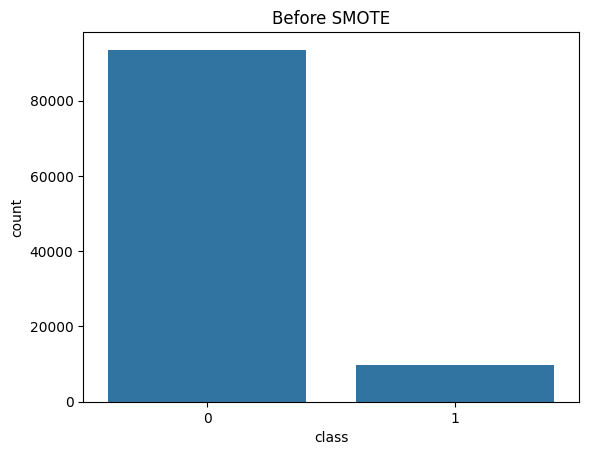

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)

plt.title("Before SMOTE")
plt.show()

In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

In [69]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [70]:
y_train_smote.value_counts()

class
0    93502
1    93502
Name: count, dtype: int64

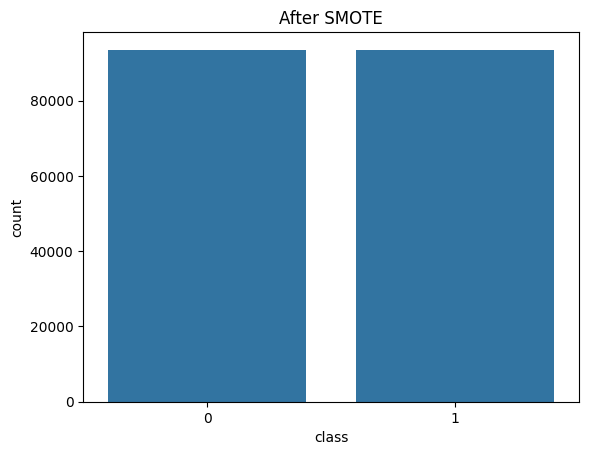

In [71]:
sns.countplot(x=y_train_smote)

plt.title("After SMOTE")
plt.show()

In [72]:
train_processed = pd.concat(
    [
        pd.DataFrame(X_train_smote),
        pd.Series(y_train_smote, name='class')
    ],
    axis=1
)

In [73]:
test_processed = pd.concat(
    [
        pd.DataFrame(X_test),
        pd.Series(y_test, name='class')
    ],
    axis=1
)

In [ ]:
train_processed.to_csv(
    "../data/processed/fraud_train_processed.csv",
    index=False
)

test_processed.to_csv(
    "../data/processed/fraud_test_processed.csv",
    index=False
)